In [1]:
import firedrake
import numpy as np
import pickle as pkl
from numpy import pi as π
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import firedrake
from firedrake import Constant, inner, sqrt, tr, grad, div, as_vector, exp,sym, as_vector, dx, ds, Mesh, Function, project, TransferManager
import meshpy, meshpy.geometry, meshpy.triangle
import irksome
from irksome import Dt
from scipy.signal import detrend
import copy
import matplotlib
import irksome
from irksome import Dt
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import pickle as pkl
import tqdm
import emcee
import corner
import itertools
import xarray
import dtscalibration
import glob
from rasterio.plot import show
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import os
import sys
from pyproj import Transformer
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from scripts.AH_temp_funcs import *
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import shapefile as sf

import rasterio
from rasterio.enums import Resampling
from rasterio.mask import mask


from firedrake import *
from firedrake.__future__ import interpolate

from scripts.mesh_generating import *

%matplotlib widget

"""
This notebook is used to save the coarse and fine meshes to be used in the model.

We create a coarse mesh then solve for the flow. Then, we create a fine mesh and
use the flow from the coarse mesh as the boundary conditions for the fine mesh.

"""



'\nThis notebook is used to save the coarse and fine meshes to be used in the model.\n\nWe create a coarse mesh then solve for the flow. Then, we create a fine mesh and\nuse the flow from the coarse mesh as the boundary conditions for the fine mesh.\n\n'

In [2]:
### Input params ###

fine_bed_path = "../Meshes/crop_aoi/main_boreholes_aoi/main_boreholes_aoi_fix_bed.tif"
fine_surf_path = "../Meshes/crop_aoi/main_boreholes_aoi/main_boreholes_aoi_fix_surf.tif"


coarse_bed_path = "../Meshes/ThreeD_meshing/bedmachine_ian_merged_bed_large_aoi_8m_aligned_fixed.tif"
coarse_surf_path = "../Meshes/ThreeD_meshing/rema_large_aoi_align_fixed.tif"

coarse_resamp_factor=1/200 
fine_resamp_factor=1/10

layers = 10

In [3]:
mesh = mesh_creator(coarse_bed_path, coarse_surf_path, resamp_factor=coarse_resamp_factor, layers=layers)

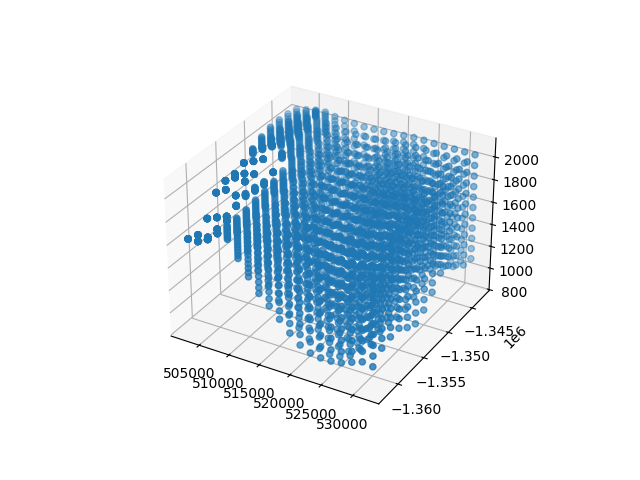

In [4]:
ax = plt.figure().add_subplot(projection='3d')

ax.scatter(mesh.coordinates.dat.data_ro[:,0], mesh.coordinates.dat.data_ro[:,1], mesh.coordinates.dat.data_ro[:,2])



In [5]:
flowline_surf = pd.read_csv('../flowlines/manual_flowlines/csv/ALHIC1902_surface_rema_100m.csv')
flowline_bed = pd.read_csv('../flowlines/manual_flowlines/csv/ALHIC1902_bed_merged_100m.csv')
flowline_xs = flowline_surf['E']
flowline_ys = flowline_surf['N']
flowline_bed_elev = flowline_bed['Elev']
flowline_surf_elev = flowline_surf['Elev']
flowline_distance = flowline_surf['Distance']

In [10]:
z_coords = np.linspace(1300, 2200, 500)

In [12]:
dummy_space_coarse = firedrake.VectorFunctionSpace(meshes[0], "CG", 3)
dummy_space_fine = firedrake.VectorFunctionSpace(meshes[1], "CG", 3)

dummy_func_coarse = firedrake.Function(dummy_space_coarse)
dummy_func_fine = firedrake.Function(dummy_space_fine)

In [15]:
coarse_coords = []
fine_coords = []

for n in range(len(flowline_xs)):


    for z_coord in z_coords:
        try:
            dummy_at = dummy_func_coarse.at(flowline_xs[n], flowline_ys[n], z_coord)[0]*spy
            distance = np.sqrt((flowline_xs[n]-flowline_xs[0])**2 + (flowline_ys[n]-flowline_ys[0])**2)
            coarse_coords.append([distance, z_coord])

        except:
            continue

for n in range(len(flowline_xs)):


    for z_coord in z_coords:
        try:
            dummy_at = dummy_func_fine.at(flowline_xs[n], flowline_ys[n], z_coord)[0]*spy
            distance = np.sqrt((flowline_xs[n]-flowline_xs[0])**2 + (flowline_ys[n]-flowline_ys[0])**2)
            fine_coords.append([distance, z_coord])

        except:
            continue

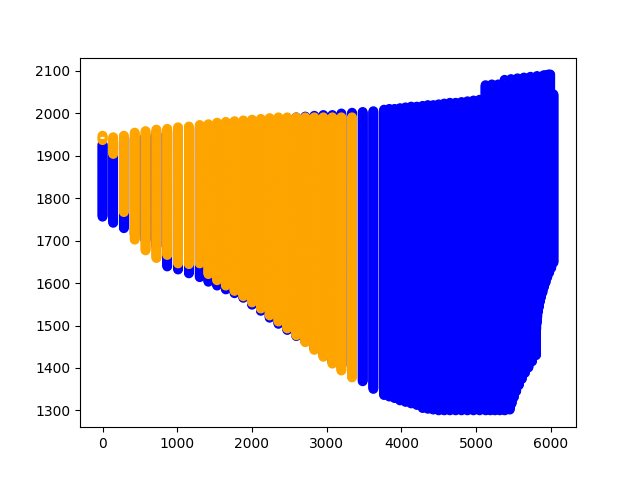

In [23]:
coarse_coords_arr = np.array(coarse_coords)
fine_coords_arr = np.array(fine_coords)

fig,ax=plt.subplots()

ax.scatter(coarse_coords_arr[:,0], coarse_coords_arr[:,1], marker='o',fc='none', ec='blue')
ax.scatter(fine_coords_arr[:,0], fine_coords_arr[:,1], marker='o',fc='none', ec='orange')